# Word Embedding + Spacy
https://en.wikipedia.org/wiki/Word_embedding

In [37]:
import zipfile
import pandas as pd
from io import TextIOWrapper
from sklearn.cluster import AgglomerativeClustering
import spacy
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from wordcloud import WordCloud

tqdm.pandas()

nlp = spacy.load("en_core_web_md")

## Load dataset

In [38]:
zip_path = '../datasets/bbc-news.zip'

data = []
with zipfile.ZipFile(zip_path, "r") as fzip:
    for file in fzip.namelist():
        if not file.startswith("bbc news summary/BBC News Summary/News Articles/"):
            continue
        if file.endswith(".txt"):
            parts = file.split("/")
            category = parts[-2]
            with fzip.open(file) as f:
                content = TextIOWrapper(f, encoding='latin1').read().strip()
                data.append({'text': content, 'category': category})

df = pd.DataFrame(data)
df.head()

,text,category
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [39]:
df.category.value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

## Load stopwords

In [40]:
stopwords = nlp.Defaults.stop_words
custom_stopwords = stopwords.union({'mr', 'ms', 'v', 'i'})

## Create a new column with NLP processed text

In [41]:
df['doc'] = df.text.progress_apply(lambda text: nlp(text.lower()))
df

  0%|          | 0/2225 [00:00<?, ?it/s]

,text,category,doc
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,"(ad, sales, boost, time, warner, profit, \n\n,..."
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,"(dollar, gains, on, greenspan, speech, \n\n, t..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,"(yukos, unit, buyer, faces, loan, claim, \n\n,..."
3,High fuel prices hit BA's profits\n\nBritish A...,business,"(high, fuel, prices, hit, ba, 's, profits, \n\..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,"(pernod, takeover, talk, lifts, domecq, \n\n, ..."
...,...,...,...
2220,BT program to beat dialler scams\n\nBT is intr...,tech,"(bt, program, to, beat, dialler, scams, \n\n, ..."
2221,Spam e-mails tempt net shoppers\n\nComputer us...,tech,"(spam, e, -, mails, tempt, net, shoppers, \n\n..."
2222,Be careful how you code\n\nA new European dire...,tech,"(be, careful, how, you, code, \n\n, a, new, eu..."
2223,US cyber security chief resigns\n\nThe man mak...,tech,"(us, cyber, security, chief, resigns, \n\n, th..."


## Create a new column with lemma processed text

In [42]:
df['lemma'] = df.doc.progress_apply(lambda doc: [
    token.lemma_ for token in doc
    if (len(token) > 2) and
        token.is_alpha and
         (token.lemma_ not in custom_stopwords)])
df

  0%|          | 0/2225 [00:00<?, ?it/s]

,text,category,doc,lemma
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,"(ad, sales, boost, time, warner, profit, \n\n,...","[sale, boost, time, warner, profit, quarterly,..."
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,"(dollar, gains, on, greenspan, speech, \n\n, t...","[dollar, gain, greenspan, speech, dollar, hit,..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,"(yukos, unit, buyer, faces, loan, claim, \n\n,...","[yukos, unit, buyer, face, loan, claim, owner,..."
3,High fuel prices hit BA's profits\n\nBritish A...,business,"(high, fuel, prices, hit, ba, 's, profits, \n\...","[high, fuel, price, hit, profit, british, airw..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,"(pernod, takeover, talk, lifts, domecq, \n\n, ...","[pernod, takeover, talk, lift, domecq, share, ..."
...,...,...,...,...
2220,BT program to beat dialler scams\n\nBT is intr...,tech,"(bt, program, to, beat, dialler, scams, \n\n, ...","[program, beat, dialler, scam, introduce, init..."
2221,Spam e-mails tempt net shoppers\n\nComputer us...,tech,"(spam, e, -, mails, tempt, net, shoppers, \n\n...","[spam, mail, tempt, net, shopper, computer, us..."
2222,Be careful how you code\n\nA new European dire...,tech,"(be, careful, how, you, code, \n\n, a, new, eu...","[careful, code, new, european, directive, soft..."
2223,US cyber security chief resigns\n\nThe man mak...,tech,"(us, cyber, security, chief, resigns, \n\n, th...","[cyber, security, chief, resign, man, sure, co..."


## Create a new column with embedding vectors

In [43]:
df['vectors'] = df.doc.progress_apply(lambda doc: np.array(doc.vector))
df

  0%|          | 0/2225 [00:00<?, ?it/s]

,text,category,doc,lemma,vectors
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,"(ad, sales, boost, time, warner, profit, \n\n,...","[sale, boost, time, warner, profit, quarterly,...","[-0.7193304, 0.30883816, -0.039744046, -0.0432..."
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,"(dollar, gains, on, greenspan, speech, \n\n, t...","[dollar, gain, greenspan, speech, dollar, hit,...","[-0.70262104, 0.23647642, -0.08732762, -0.0123..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,"(yukos, unit, buyer, faces, loan, claim, \n\n,...","[yukos, unit, buyer, face, loan, claim, owner,...","[-0.6459558, 0.20119494, -0.12081968, -0.03655..."
3,High fuel prices hit BA's profits\n\nBritish A...,business,"(high, fuel, prices, hit, ba, 's, profits, \n\...","[high, fuel, price, hit, profit, british, airw...","[-0.6972988, 0.2964666, -0.014015451, -0.03825..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,"(pernod, takeover, talk, lifts, domecq, \n\n, ...","[pernod, takeover, talk, lift, domecq, share, ...","[-0.676196, 0.1873766, -0.010159899, -0.052733..."
...,...,...,...,...,...
2220,BT program to beat dialler scams\n\nBT is intr...,tech,"(bt, program, to, beat, dialler, scams, \n\n, ...","[program, beat, dialler, scam, introduce, init...","[-0.7109693, 0.2081351, -0.1625676, -0.0585224..."
2221,Spam e-mails tempt net shoppers\n\nComputer us...,tech,"(spam, e, -, mails, tempt, net, shoppers, \n\n...","[spam, mail, tempt, net, shopper, computer, us...","[-0.73549604, 0.22394745, -0.15800534, -0.0696..."
2222,Be careful how you code\n\nA new European dire...,tech,"(be, careful, how, you, code, \n\n, a, new, eu...","[careful, code, new, european, directive, soft...","[-0.7095644, 0.19630948, -0.16856484, -0.07718..."
2223,US cyber security chief resigns\n\nThe man mak...,tech,"(us, cyber, security, chief, resigns, \n\n, th...","[cyber, security, chief, resign, man, sure, co...","[-0.7274873, 0.18809457, -0.118178, -0.0372324..."


## Split into 10 clusters

In [ ]:
vectors = np.stack(df.vectors.values)
cluster_model = AgglomerativeClustering(n_clusters=10)
df['cluster'] = cluster_model.fit_predict(vectors)

# Check the cluster sizes x categories
category_by_cluster = pd.crosstab(df.cluster, df.category)
category_by_cluster

category,business,entertainment,politics,sport,tech
cluster,,,,,
0,219,6,112,2,25
1,19,14,23,1,310
2,1,69,60,230,7
3,250,0,2,0,3
4,0,161,1,2,0
5,13,34,132,53,4
6,0,2,0,28,0
7,2,4,0,173,0
8,1,20,82,14,39


In [ ]:
tsne = TSNE(n_components=2, random_state=42, init='pca')
tsne_result = tsne.fit_transform(vectors)

df['tsne_x'], df['tsne_y'] = tsne_result[:, 0], tsne_result[:, 1]

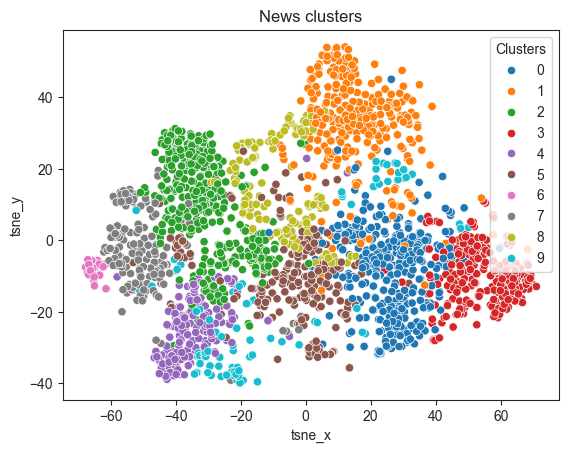

In [ ]:
sns.set_style("ticks")

sns.scatterplot(
    x='tsne_x',
    y='tsne_y',
    hue='cluster',
    palette='tab10',
    data=df)

plt.xlabel('tsne_x')
plt.ylabel('tsne_y')
plt.title('News clusters')
plt.legend(title='Clusters')

In [74]:
category_by_cluster = pd.crosstab(df.cluster, df.category)
category_by_cluster

category,business,entertainment,politics,sport,tech
cluster,,,,,
0,219,6,112,2,25
1,19,14,23,1,310
2,1,69,60,230,7
3,250,0,2,0,3
4,0,161,1,2,0
5,13,34,132,53,4
6,0,2,0,28,0
7,2,4,0,173,0
8,1,20,82,14,39


## Plot wordcloud

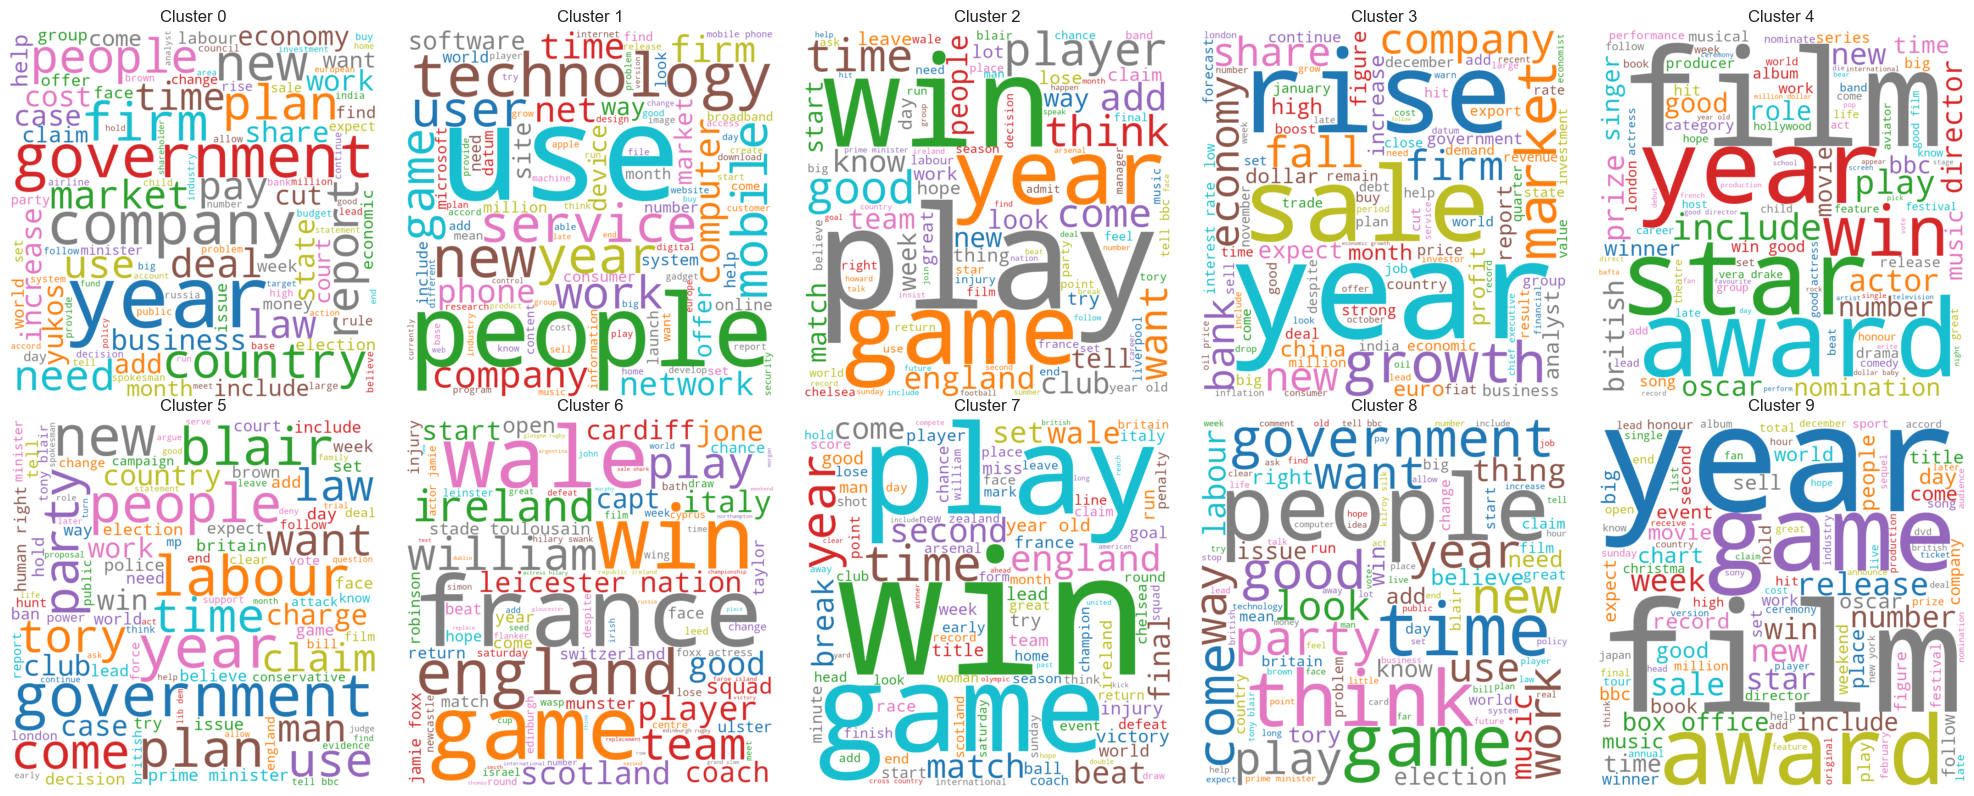

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))


for cluster_id in sorted(df.cluster.unique()):
    texts = []
    cluster_df = df[df.cluster == cluster_id]
    for text in cluster_df.lemma.tolist():
        texts.extend(text)
    text = " ".join(texts)
    wordcloud = WordCloud(width=800, height=800,
                          background_color='white',
                          colormap='tab10', max_words=100).generate(text)
    ax = axes.flatten()[cluster_id]
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'Cluster {cluster_id}')
    ax.axis('off')
fig.tight_layout()